In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Introduction
<p>One of the many hazards of wildfires are the atmospheric pollutants they emit into the local area. Current efforts to predict the volume and spatial extent of these pollutans have yielded various levels of success. In this notebook, the focus is centered on the Southern California region, with an emphasis on ozone and PM2.5 prediction.</p>

<p>This is my code where I attempt to predict pollutant levels (PM2.5/Ozone). The first step was to find locations where the sensors showed signs of significant wildfire influence. The example below is from the sensor located in Escondido, California, a neighborhoood near San Diego in the year 2007.</p>

/var/folders/21/m_vgj_jx03d_1jzdffrlp2080000gn/T/ipykernel_41029/3466743104.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pm_df['Date'] = pd.to_datetime(pm_df['Date'], format='%m/%d/%Y')
/var/folders/21/m_vgj_jx03d_1jzdffrlp2080000gn/T/ipykernel_41029/3466743104.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pm_df['Day in Year (Local)'] = pm_df['Date'].dt.dayofyear
/var/folders/21/m_vgj_jx03d_1jzdffrlp2080000gn/T/ipykernel_41029/3466743104.py:13: SettingWithCopyWarning: 
A value is trying to be s

Text(0.5, 0, 'Day in Year')

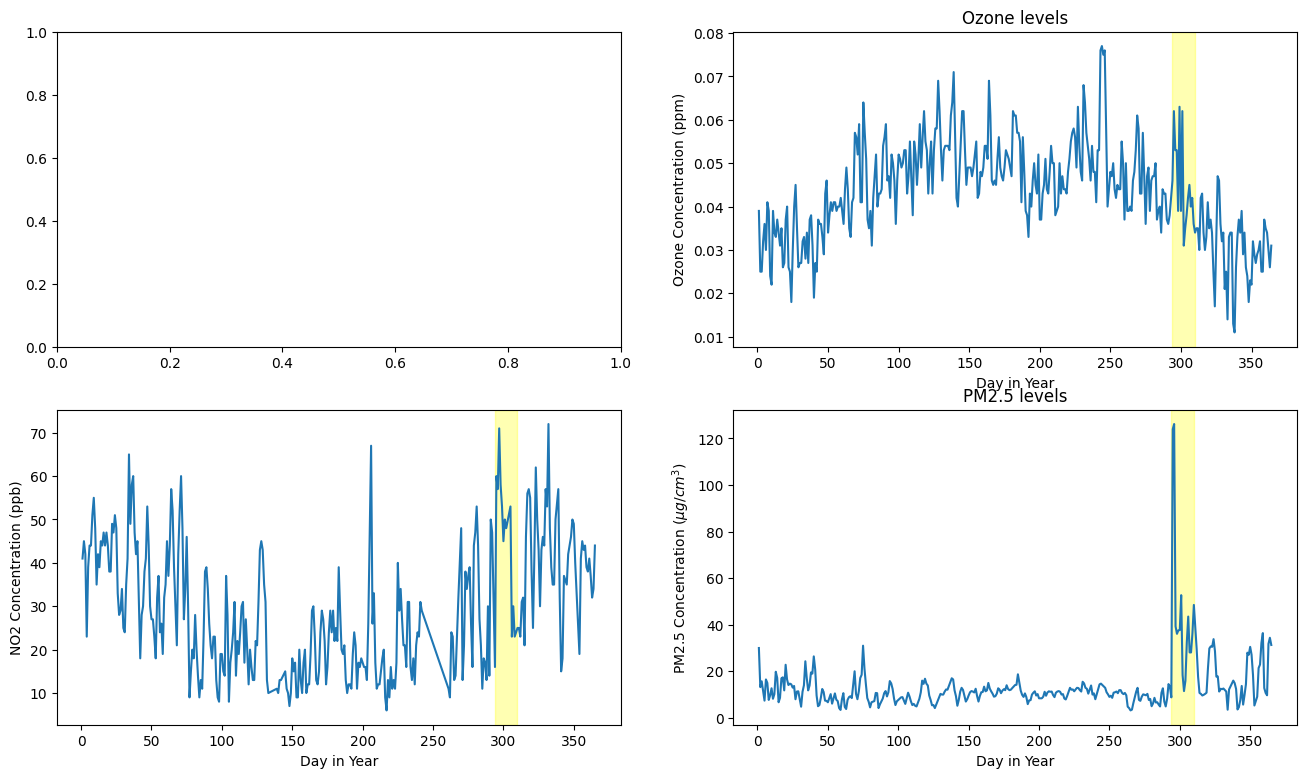

In [3]:
countyName = "Escondido"

df = pd.read_csv("sandiegocountydata2007.csv")


pm_df= df[(df["Local Site Name"] == countyName) & (df["POC"]==1)]# Some stations measure every day or every 3 days
pm_df['Date'] = pd.to_datetime(pm_df['Date'], format='%m/%d/%Y')
pm_df['Day in Year (Local)'] = pm_df['Date'].dt.dayofyear

df = pd.read_csv("sandiegoozonedata2007.csv")

ozone_df= df[df["Local Site Name"] == countyName ]
ozone_df['Date'] = pd.to_datetime(ozone_df['Date'], format='%m/%d/%Y')
ozone_df['Day in Year (Local)'] = ozone_df['Date'].dt.dayofyear

df = pd.read_csv("sandiegoNO2data.csv")

no2_df= df[df["Local Site Name"] == countyName ]
no2_df['Date'] = pd.to_datetime(no2_df['Date'], format='%m/%d/%Y')
no2_df['Day in Year (Local)'] = no2_df['Date'].dt.dayofyear

# NOTE: THe original intent for this project was to consider CO (carbon monoxide) as a proxy for wildfire intensity. Limited data in various locations made this 
# quite difficult to implement.
fig, ax = plt.subplots(2,2, figsize= (16,9))
#ax[0,0].plot(co_df["Day In Year (Local)"], co_df["Arithmetic Mean"])
ax[0,1].plot(ozone_df["Day in Year (Local)"], ozone_df["Daily Max 8-hour Ozone Concentration"])
ax[0,1].axvspan(294, 310, color='yellow', alpha=0.3, label='Highlighted Region (Days 100-200)')
#ax[1,0].plot(no_df["Day In Year (Local)"], no_df["Arithmetic Mean"])
ax[1,1].plot(pm_df["Day in Year (Local)"], pm_df["Daily Mean PM2.5 Concentration"])
ax[1,1].axvspan(294, 310, color='yellow', alpha=0.3, label='Highlighted Region (Days 100-200)')
ax[1,0].plot(no2_df["Day in Year (Local)"], no2_df["Daily Max 1-hour NO2 Concentration"])
ax[1,0].axvspan(294, 310, color='yellow', alpha=0.3, label='Highlighted Region (Days 100-200)')

#ax[0,0].set_title("Carbon monoxide levels")
ax[0,1].set_title("Ozone levels")
ax[1,1].set_title("PM2.5 levels")

ax[0,1].set_ylabel("Ozone Concentration (ppm)")
ax[1,1].set_ylabel("PM2.5 Concentration ($\mu g/cm^3$)")
ax[1,0].set_ylabel("NO2 Concentration (ppb)")

ax[0,1].set_xlabel("Day in Year")
ax[1,1].set_xlabel("Day in Year")
ax[1,0].set_xlabel("Day in Year")




<p>The most obvious signal here is that for PM2.5, where the levels spike to over $120\mu g/cm^3$. (I have highlighted the period of the Escondido wildfire in yellow for ease of reference.) If we look at the time series for both $O_3$ and $NO_2$, it may seem that the wildfire could have also influenced their respective levels, but in context of the annual series, wildfire does not seem to be the primary cause of their presence at the time.</p>

## Wrangling Data for ML Model

<p>Now that we have an idea for what is going during and outside a wildfire period, let us gather idea for variables we may think that influence the presence of ozone.</p>
<p>The following variables were used in the implementation of the model: maximum temperature, wind speed, maximum relative humidity, average precipitation, daily max 1-hour $NO_2$ concentration. These variables were chosen due to their influence on aerosols.</p>
<p>The data used here is sourced from the <a href="https://www.climatologylab.org/gridmet.html">gridMET dataset</a>. NOTE: When using csv files downloaded from this dataset, the dates section may not have a "Date" header. You may need to manually go into Excel to add this header so that the code can work.</p>

In [4]:
temp_df = pd.read_csv("EscondidoMaxTemp2007.csv")

temp_df['Date'] = pd.to_datetime(temp_df['Date'],format="mixed")
temp_df['Date'] = temp_df['Date'].dt.dayofyear
temp_df= temp_df.rename(columns={"(deg C) Maximum Temperature (gridMET) at -117.0751E,33.1278N, 2007-01-01 to 2007-12-31": "Max Temperature (deg C)"})

In [5]:
df_rhmax = pd.read_csv("EscondidoRHMax2007.csv")
df_rhmax['Date'] = pd.to_datetime(df_rhmax['Date'],format="mixed")
df_rhmax['Date'] = df_rhmax['Date'].dt.dayofyear
df_rhmax= df_rhmax.rename(columns={"(%) Maximum Relative Humidity (gridMET) at -117.0751E,33.1278N, 2007-01-01 to 2007-12-31": "Max Relative Humidity (%)"})

In [6]:
precip_df = pd.read_csv("EscondidoPrecipData2007.csv")

precip_df['Date'] = pd.to_datetime(precip_df['Date'],format="mixed")
precip_df['Date'] = precip_df['Date'].dt.dayofyear
precip_df= precip_df.rename(columns={"(mm) Precipitation (gridMET) at -117.0751E,33.1278N, 2007-01-01 to 2007-12-31": "Precipitation (mm)"})

In [7]:
wspeed_df = pd.read_csv("EscondidoWindSpeed2007.csv")

wspeed_df['Date'] = pd.to_datetime(wspeed_df['Date'],format="mixed")
wspeed_df['Date'] = wspeed_df['Date'].dt.dayofyear
wspeed_df= wspeed_df.rename(columns={"(m/s) Wind Speed (gridMET) at -117.0751E,33.1278N, 2007-01-01 to 2007-12-31": "Wind Speed (m/s)"})

In [8]:
combined_df = temp_df.merge(
    ozone_df[["Day in Year (Local)", "Daily Max 8-hour Ozone Concentration"]],
    left_on="Date", right_on="Day in Year (Local)", how="outer"
).merge(
    no2_df[["Day in Year (Local)", "Daily Max 1-hour NO2 Concentration"]],
    left_on="Date", right_on="Day in Year (Local)", how="outer"
).merge(
    precip_df[["Date", "Precipitation (mm)"]],
    left_on="Date", right_on="Date", how="outer"
).merge(
    df_rhmax[["Date", "Max Relative Humidity (%)"]],
    left_on="Date", right_on="Date", how="outer"
).merge(
    wspeed_df[["Date", "Wind Speed (m/s)"]],
    left_on="Date", right_on="Date", how="outer"
).merge(
    pm_df[["Day in Year (Local)", "Daily Mean PM2.5 Concentration"]],
    left_on="Date", right_on="Day in Year (Local)", how="outer")


In [12]:
combined_df

,Date,Max Temperature (deg C),Day in Year (Local)_x,Daily Max 8-hour Ozone Concentration,Day in Year (Local)_y,Daily Max 1-hour NO2 Concentration,Precipitation (mm),Max Relative Humidity (%),Wind Speed (m/s),Day in Year (Local),Daily Mean PM2.5 Concentration
0,1,17.4900,1.0,0.039,1.0,41.0,0.0000,87.8719,2.8844,1.0,30.0
1,2,21.6389,2.0,0.025,2.0,45.0,0.0000,77.6652,3.7027,2.0,13.2
2,3,21.9393,3.0,0.025,3.0,42.0,0.0000,45.0867,2.4738,3.0,15.7
3,4,19.3995,4.0,0.032,4.0,23.0,0.9485,82.6117,3.2027,NaN,NaN
4,5,16.8400,5.0,0.036,5.0,39.0,1.6789,100.0000,7.0025,5.0,7.4
...,...,...,...,...,...,...,...,...,...,...,...
360,361,13.6722,361.0,0.034,361.0,41.0,0.0000,94.9859,5.1351,361.0,10.7
361,362,13.3017,362.0,0.030,362.0,37.0,0.0000,48.2264,1.8248,362.0,9.7
362,363,15.4524,363.0,0.026,363.0,32.0,0.0000,99.5734,2.1767,363.0,31.8
363,364,17.6217,364.0,0.031,364.0,34.0,0.0000,100.0000,2.1138,364.0,34.4


In [9]:
combined_df =combined_df.dropna()
#Drop all the extra "Date" columns, They tend to be labeled as Date_x Date_y, so this accounts for as many as possible
combined_df = combined_df.drop(columns=[col for col in combined_df.columns if col.startswith("Day in Year")])

In [14]:
combined_df

,Date,Max Temperature (deg C),Daily Max 8-hour Ozone Concentration,Daily Max 1-hour NO2 Concentration,Precipitation (mm),Max Relative Humidity (%),Wind Speed (m/s),Daily Mean PM2.5 Concentration
0,1,17.4900,0.039,41.0,0.0000,87.8719,2.8844,30.0
1,2,21.6389,0.025,45.0,0.0000,77.6652,3.7027,13.2
2,3,21.9393,0.025,42.0,0.0000,45.0867,2.4738,15.7
4,5,16.8400,0.036,39.0,1.6789,100.0000,7.0025,7.4
5,6,18.5291,0.030,44.0,0.0000,47.2597,4.5706,16.5
...,...,...,...,...,...,...,...,...
359,360,18.0920,0.035,38.0,0.5233,38.0399,3.1214,12.8
360,361,13.6722,0.034,41.0,0.0000,94.9859,5.1351,10.7
361,362,13.3017,0.030,37.0,0.0000,48.2264,1.8248,9.7
362,363,15.4524,0.026,32.0,0.0000,99.5734,2.1767,31.8


## Creating our ML Model
<p>Now that we have wrangled our desired variables, we can put them through a random forest regressor to see how well we can predict the resultant ozone.</p>

In [10]:
from sklearn.model_selection import train_test_split
from sklearn. ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.tree import plot_tree

In [11]:
# Our training data shall be composed of NON-wildfire days
X = combined_df[(combined_df['Date'] < 294) | (combined_df['Date'] > 310)].drop(columns=["Date","Daily Max 8-hour Ozone Concentration"])
y = combined_df[(combined_df['Date']<294)|(combined_df['Date']>310)][["Daily Max 8-hour Ozone Concentration"]]
#Partition the data into training/testing splits
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

<p>The hyperparameters in the following model were determined by running a cross validation using GridSearch. Because the CV process can take several minutes, it will not be run here. The code is left here for reference however.  </p>

In [ ]:
"""
param_grid ={
      'n_estimators':np.arange(0,31),
        'random_state':np.arange(0,10),
    }
grid_search = GridSearchCV(RandomForestRegressor(),
                           param_grid=param_grid)
grid_search.fit(X_train, y_train.values.ravel())
print(grid_search.best_estimator_)
"""

In [12]:
# Create the model and fit it
regressor = RandomForestRegressor(n_estimators = 24, random_state = 9)
regressor.fit(X_train,y_train.values.ravel())

RandomForestRegressor(n_estimators=24, random_state=9)

In [13]:
# Use testing data to see how well it does on data it has not seen
y_pred = regressor.predict(X_test)

<p>Now that we have run our testing data through our model, let us plot the predicted ozone levels against the actual levels to visually determine its performance.</p>

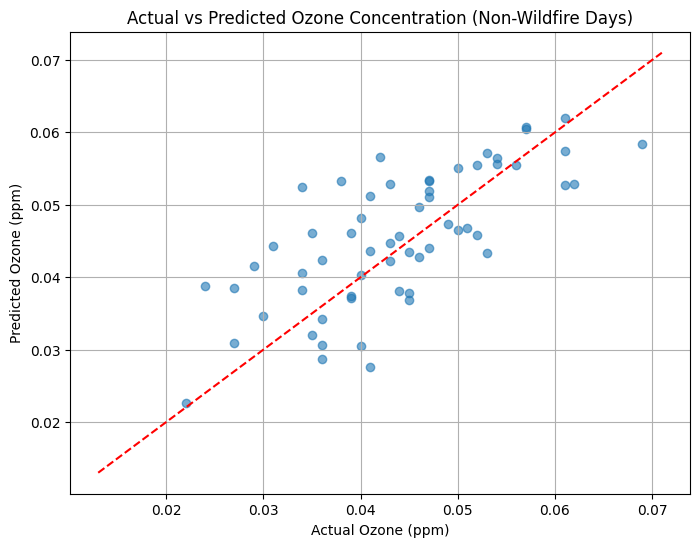

In [14]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.xlabel("Actual Ozone (ppm)")
plt.ylabel("Predicted Ozone (ppm)")
plt.title("Actual vs Predicted Ozone Concentration (Non-Wildfire Days)")
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')  #Line of perfect prediction
plt.grid(True)
plt.show()

In [15]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [16]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("Mean Absolute Error:",mae) #MAE is in same units (ppm), so the error is about 6ppb
print("RMSE: ",rmse)

Mean Absolute Error: 0.006018750000000002
RMSE:  0.00738979409137785


<p>The red line in the chart above represents a perfect prediction of ozone. As we can see, most of the predictions are somewhat closely scattered around the line. To quantify the prediction error, the mean absolute error and root mean squared error are provided. The MAE in this prediction set is about 0.006 ppm, or 6 ppb. For a metric like 8 Hour ozone concentrations, this is decent, though there is room for improvement.</p>

### Wildfire Ozone Levels

<p>We have used our data to predict ozone when there are no local wildfires, but how well does the model perform when given wildfire conditions?</p>

In [17]:
X_wildfire = combined_df[(combined_df['Date'] >= 294) & (combined_df['Date'] <= 310)].drop(columns = ["Date","Daily Max 8-hour Ozone Concentration"])
y_wildfire = combined_df[(combined_df['Date']>=294)&(combined_df['Date']<=310)][["Daily Max 8-hour Ozone Concentration"]]

In [18]:
y_pred_wildfire = regressor.predict(X_wildfire)

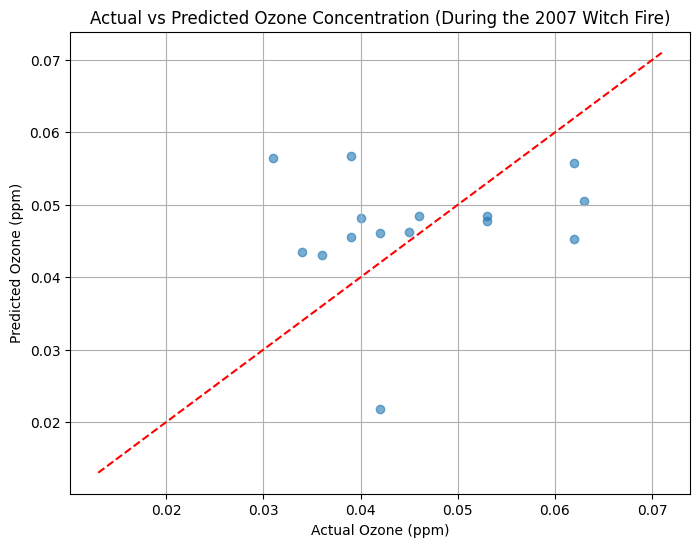

In [19]:
plt.figure(figsize=(8,6))
plt.scatter(y_wildfire, y_pred_wildfire, alpha=0.6)
plt.xlabel("Actual Ozone (ppm)")
plt.ylabel("Predicted Ozone (ppm)")
plt.title("Actual vs Predicted Ozone Concentration (During the 2007 Witch Fire)")
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')  #Line of perfect prediction
plt.grid(True)
plt.show()

In [20]:
mae = mean_absolute_error(y_wildfire, y_pred_wildfire)
rmse = np.sqrt(mean_squared_error(y_wildfire, y_pred_wildfire))
print("Mean Absolute Error:",mae) #MAE is in same units, so the error is about 6ppb
print("RMSE: ",rmse)

Mean Absolute Error: 0.009841666666666669
RMSE:  0.012018711299315593


<p>As we can see, the model is less capable of predicting ozone during a wildfire. There are only 15 data points that could be tested for this specific event, so the capability of this model may not be as accurate as it appears here. However, when considering the original time series above, the amounts of ozone did not change too drastically during the wildfire compared to before and after the fire. Given the similarities between wildfire and non-wildfire ozone levels, the model's prediction are not likely to be significantly impacted.</p>

### Predicting PM2.5 Pollution
<p>To make a model to predict PM2.5 pollution levels, we repeat the same steps as before, this time making Daily Mean PM2.5 concentration the variable to be predicted.</p>

In [21]:
X = combined_df[(combined_df['Date'] < 294) | (combined_df['Date'] > 310)].drop(columns=["Date","Daily Max 8-hour Ozone Concentration","Daily Mean PM2.5 Concentration"])
y = combined_df[(combined_df['Date']<294)|(combined_df['Date']>310)][["Daily Mean PM2.5 Concentration"]]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [22]:
regressor = RandomForestRegressor(n_estimators = 24, random_state = 9)
regressor.fit(X_train,y_train.values.ravel())

RandomForestRegressor(n_estimators=24, random_state=9)

In [23]:
y_pred = regressor.predict(X_test)

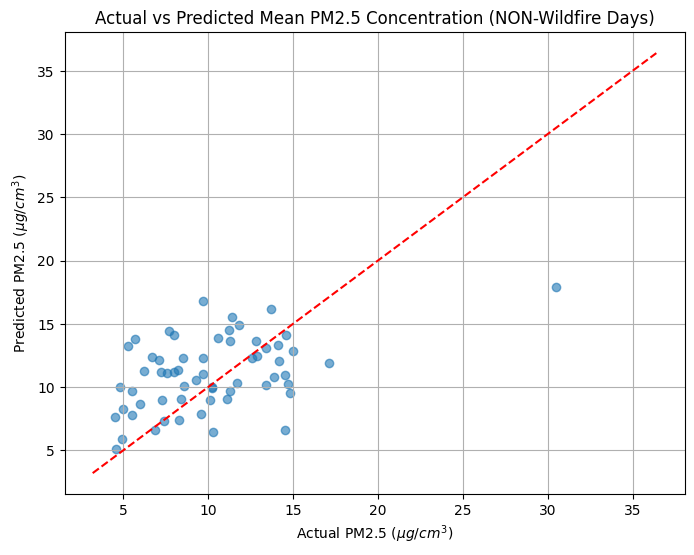

In [25]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.xlabel("Actual PM2.5 ($\mu g/cm^3$)")
plt.ylabel("Predicted PM2.5 ($\mu g/cm^3$)")
plt.title("Actual vs Predicted Mean PM2.5 Concentration (NON-Wildfire Days)")
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')  #Line of perfect prediction
plt.grid(True)
plt.show()

In [26]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("Mean Absolute Error:",mae) #MAE is in same units
print("RMSE: ",rmse)

Mean Absolute Error: 3.095416666666666
RMSE:  3.9422556524951076


<p>As we can see, the model also seems to perform decently well at predicting PM2.5 concentrations during non-wildfire conditions. Now let's see what happens when there is a fire.</p>

### Wildfire Days only (PM2.5 prediction)

In [27]:
X_wildfire = combined_df[(combined_df['Date'] >= 294) & (combined_df['Date'] <= 310)].drop(columns=["Date","Daily Max 8-hour Ozone Concentration","Daily Mean PM2.5 Concentration"])
y_wildfire = combined_df[(combined_df['Date'] >=294)&(combined_df['Date']<=310)][["Daily Mean PM2.5 Concentration"]]

In [28]:
y_pred = regressor.predict(X_wildfire)

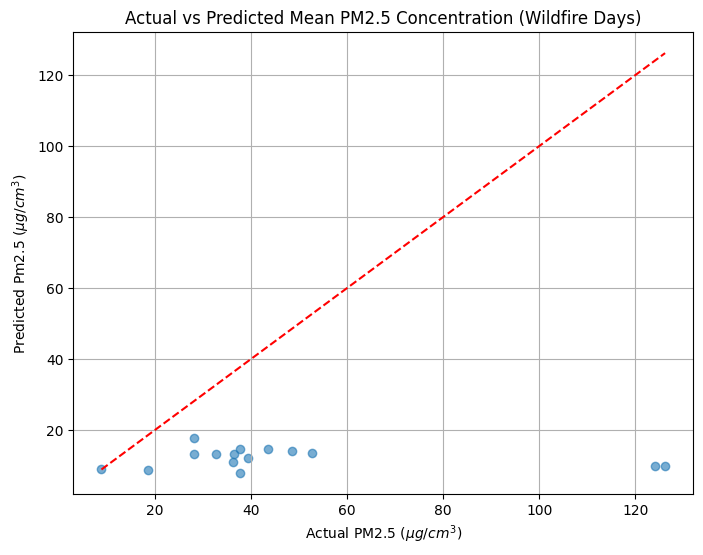

In [30]:
plt.figure(figsize=(8,6))
plt.scatter(y_wildfire, y_pred, alpha=0.6)
plt.xlabel("Actual PM2.5 ($\mu g/cm^3$)")
plt.ylabel("Predicted Pm2.5 ($\mu g/cm^3$)")
plt.title("Actual vs Predicted Mean PM2.5 Concentration (Wildfire Days)")
plt.plot([y_wildfire.min(), y_wildfire.max()], [y_wildfire.min(), y_wildfire.max()], 'r--')  #Line of perfect prediction
plt.grid(True)
plt.show()

In [39]:
mae = mean_absolute_error(y_wildfire, y_pred)
rmse = np.sqrt(mean_squared_error(y_wildfire, y_pred))
print("Mean Absolute Error:",mae) #MAE is in same units
print("RMSE: ",rmse)

Mean Absolute Error: 34.433888888888895
RMSE:  47.80751062081416


<p>The error for wildfire days increases by about ten fold. This is expected, as our model is only trained on non-wildfire days, so it unlikely to be as accurate when provided with severe wildfire conditions it is not used to seeing. This becomes most prominent during extreme days such as the two where the PM2.5 concentration was over $120\mu g/cm^3$. From this graph, we can conclude that there are some relationships/external variables not accouted in our model that may explain the sudden increase in the amount of pollution we see.</p>

## Conclusions

<p>This project explored the impacts of wildfire on PM2.5 and ozone concentrations through the use of a random forest regression model. The model worked reasonably well on non-wildfire days but was less effective in predicting PM2.5 concentrations during wildfire conditions. The discrepenacy suggests there are several wildfire realted variables not accounted for within the model.</p>
<p>It is important to note that the meteorological variables used in this model are not all direct causes of wildfires, but are simply used as proxies for wildfire conditions. For example, high temperatures by themselves do not necessarily always lead to wildfires, but the proliferation of fire is dependent on the amount of dry fuel available in the local area, which is partly dependent on the local temperature.</p>
<p>Future work should incorporate a more comprehensive understanding of Southern California wildfire regimes and include other types of data such as smoke plume and fire perimeter data. Additionally, other types of machine learning models, such as gradient boosting or neural networks, should be considered to enhance performance.</p>

## Data Sources

<p><a href="https://www.climatologylab.org/gridmet.html">gridMet Data</a>: Abatzoglou, J. T. (2013), Development of gridded surface meteorological data for ecological applications and modelling. Int. J. Climatol., 33: 121–131.</p>
<p><a href="https://www.epa.gov/outdoor-air-quality-data">U.S EPA Air Quality Data</a>: US Environmental Protection Agency. Air Quality System Data Mart available via https://www.epa.gov/outdoor-air-quality-data. Accessed March 01, 2025.</p>